# MuJoCo Warp Renderer Parity & Benchmarks

This notebook validates the Phase 1 renderer parity work and benchmarks the
mjwarp ray-traced renderer against `mujoco.Renderer` (OpenGL).

Each section exercises one of the lighting / material features wired up in
the Phase 1 PR:

1. **Headlight** — `vis.headlight` injection at the active camera\n
2. **Spotlight cutoff & exponent** — `light_cutoff`, `light_exponent`\n
3. **Distance attenuation** — `light_attenuation` 3-coefficient model\n
4. **Per-light color** — independent diffuse / specular per light\n
5. **Specular highlights** — Phong `mat_specular` / `mat_shininess`\n
6. **Material emission** — `mat_emission` self-illumination\n
7. **Shadows** — binary shadow rays

The final section times both renderers across resolutions and world counts.

> Run on a CUDA-enabled Warp build for meaningful multi-world benchmarks.
> On CPU the timings are still informative but rendering thousands of
> environments at once is not the design point.

## Setup

In [1]:
import time

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import warp as wp

import mujoco_warp as mjw

wp.init()
print("Warp devices:", [str(d) for d in wp.get_devices()])
print("CUDA devices:", wp.get_cuda_device_count())

Warp 1.13.0.dev20260227 initialized:
   Git commit: 0e622012c4291df7ad57cd8b6038d3498c6b5f60
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/mhasek/Library/Caches/warp/1.13.0.dev20260227
Warp devices: ['cpu']
CUDA devices: 0


In [2]:
def _unpack_rgb(packed: np.ndarray) -> np.ndarray:
  r = ((packed >> 16) & 0xFF).astype(np.uint8)
  g = ((packed >> 8) & 0xFF).astype(np.uint8)
  b = (packed & 0xFF).astype(np.uint8)
  return np.stack([r, g, b], axis=-1)


def mjwarp_render(
  mjm: mujoco.MjModel,
  w: int,
  h: int,
  use_shadows: bool = True,
  samples_per_pixel: int = 4,
) -> np.ndarray:
  """Render `mjm` with mjwarp at WxH. Returns an HxWx3 uint8 RGB image.

  Defaults match `mujoco.Renderer` for symmetric comparison: shadows are on
  (matching `mjRND_SHADOW`) and 4x MSAA is enabled. Pass `samples_per_pixel=1`
  for the raw single-sample output, or `use_shadows=False` to isolate the
  shading contribution.
  """
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(
    mjm,
    cam_res=(w, h),
    render_rgb=True,
    use_shadows=use_shadows,
    samples_per_pixel=samples_per_pixel,
  )
  mjw.render(m, d, rc)
  return _unpack_rgb(rc.rgb_data.numpy()[0]).reshape(h, w, 3)


def mujoco_render(mjm: mujoco.MjModel, w: int, h: int, use_shadows: bool = True) -> np.ndarray:
  """Render `mjm` with mujoco.Renderer at WxH. Returns an HxWx3 uint8 RGB image.

  Pass `use_shadows=False` to disable `mjRND_SHADOW` for symmetric comparison
  with mjwarp in shadow-off mode.
  """
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    r.update_scene(mjd, camera=0)
    r.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = 1 if use_shadows else 0
    return r.render()


def mean_l1(a: np.ndarray, b: np.ndarray) -> float:
  return float(np.abs(a.astype(np.float32) - b.astype(np.float32)).mean() / 255.0)


def ssim_luma(a: np.ndarray, b: np.ndarray, win: int = 8) -> float:
  """Compact box-window SSIM on luma. Same implementation as the parity tests."""
  ay = (0.299 * a[..., 0] + 0.587 * a[..., 1] + 0.114 * a[..., 2]).astype(np.float32) / 255.0
  by = (0.299 * b[..., 0] + 0.587 * b[..., 1] + 0.114 * b[..., 2]).astype(np.float32) / 255.0
  c1, c2 = (0.01) ** 2, (0.03) ** 2
  h, w = ay.shape
  hh, ww = h - h % win, w - w % win
  ay = ay[:hh, :ww].reshape(hh // win, win, ww // win, win)
  by = by[:hh, :ww].reshape(hh // win, win, ww // win, win)
  ay = ay.transpose(0, 2, 1, 3).reshape(-1, win * win)
  by = by.transpose(0, 2, 1, 3).reshape(-1, win * win)
  mu_a, mu_b = ay.mean(axis=1), by.mean(axis=1)
  va, vb = ay.var(axis=1), by.var(axis=1)
  cov = ((ay - mu_a[:, None]) * (by - mu_b[:, None])).mean(axis=1)
  num = (2 * mu_a * mu_b + c1) * (2 * cov + c2)
  den = (mu_a**2 + mu_b**2 + c1) * (va + vb + c2)
  return float((num / den).mean())


def compare_renders(title: str, mjm: mujoco.MjModel, w: int = 128, h: int = 128, use_shadows: bool = True):
  """Render `mjm` with both backends and plot side-by-side with diff and metrics.

  `use_shadows` is applied symmetrically to both renderers so the comparison
  isolates lighting / shading parity rather than shadow-flag asymmetry.
  """
  warp_rgb = mjwarp_render(mjm, w, h, use_shadows=use_shadows)
  mj_rgb = mujoco_render(mjm, w, h, use_shadows=use_shadows)
  diff = np.abs(warp_rgb.astype(np.int32) - mj_rgb.astype(np.int32)).clip(0, 255).astype(np.uint8)

  ssim = ssim_luma(warp_rgb, mj_rgb)
  l1 = mean_l1(warp_rgb, mj_rgb)

  fig, axes = plt.subplots(1, 3, figsize=(11, 4))
  axes[0].imshow(mj_rgb)
  axes[0].set_title("MuJoCo OpenGL")
  axes[0].axis("off")
  axes[1].imshow(warp_rgb)
  axes[1].set_title("mjwarp ray-traced")
  axes[1].axis("off")
  axes[2].imshow(diff)
  axes[2].set_title(f"|Δ| (max={int(diff.max())})")
  axes[2].axis("off")
  fig.suptitle(f"{title}   SSIM={ssim:.3f}   meanL1={l1:.3f}")
  plt.tight_layout()
  plt.show()
  return ssim, l1


# Canonical MSAA sweep values used across the notebook. The first column of every
# multi-N grid is the MuJoCo OpenGL reference (which already does its own MSAA);
# the rest are mjwarp at increasing samples_per_pixel.
MSAA_NS = (1, 2, 4, 8, 16)


def msaa_sweep_grid(
  title: str,
  mjm: mujoco.MjModel,
  w: int = 96,
  h: int = 96,
  use_shadows: bool = True,
  ns: tuple[int, ...] = MSAA_NS,
  cell_size: float = 1.8,
):
  """Render `mjm` once with MuJoCo OpenGL and once per N in `ns` with mjwarp.

  Plots them in a single row with SSIM(N) annotations. Returns a dict
  {N: (warp_rgb, ssim, l1)} for downstream tables / asserts.
  """
  mj_rgb = mujoco_render(mjm, w, h, use_shadows=use_shadows)
  results = {}
  for n in ns:
    warp_rgb = mjwarp_render(mjm, w, h, use_shadows=use_shadows, samples_per_pixel=n)
    results[n] = (warp_rgb, ssim_luma(warp_rgb, mj_rgb), mean_l1(warp_rgb, mj_rgb))

  fig, axes = plt.subplots(1, 1 + len(ns), figsize=(cell_size * (1 + len(ns)), cell_size + 0.6))
  axes[0].imshow(mj_rgb, interpolation="nearest")
  axes[0].set_title("MuJoCo OpenGL\n(ref)", fontsize=9)
  axes[0].axis("off")
  for col, n in enumerate(ns, start=1):
    warp_rgb, ssim, _ = results[n]
    axes[col].imshow(warp_rgb, interpolation="nearest")
    axes[col].set_title(f"mjwarp\nN={n}\nSSIM={ssim:.3f}", fontsize=9)
    axes[col].axis("off")
  fig.suptitle(title)
  plt.tight_layout()
  plt.show()
  return results


def msaa_sweep_table(label: str, results: dict[int, tuple]) -> None:
  """Print a compact SSIM / L1 vs N table for the dict returned by msaa_sweep_grid."""
  print(f"{label}")
  print(f"  {'N':>3s}  {'SSIM':>7s}  {'meanL1':>8s}")
  for n, (_, ssim, l1) in results.items():
    print(f"  {n:>3d}  {ssim:>7.4f}  {l1:>8.4f}")

## 1. Headlight injection

The default MuJoCo scene has no explicit lights but `vis.headlight.active = 1`.
The MuJoCo OpenGL renderer prepends the headlight as a directional light at
the active camera; the mjwarp renderer now does the same.

Before Phase 1 this scene rendered black in mjwarp (only the hemispheric
ambient hack lit anything). After Phase 1 it matches the OpenGL output. The
remaining minor difference comes from MuJoCo's MSAA-smoothed silhouette
vs mjwarp's ray-traced edges — softened in this notebook by the default
`samples_per_pixel=4` in `mjwarp_render` (see section 8a).

nlight = 0, headlight.active = 1
Module mujoco_warp._src.io 921ea14 load on device 'cpu' took 0.45 ms  (cached)
Module mujoco_warp._src.bvh e843d00 load on device 'cpu' took 0.11 ms  (cached)
Module render__locals___render_megakernel_5d9423de bd67865 load on device 'cpu' took 0.19 ms  (cached)


Module render__locals___render_megakernel_46b2b73a 488c68d load on device 'cpu' took 479.70 ms  (compiled)


Module render__locals___render_megakernel_8d1a4118 2677cd0 load on device 'cpu' took 471.80 ms  (compiled)


Module render__locals___render_megakernel_243ff2fd f430c4f load on device 'cpu' took 471.17 ms  (compiled)


Module render__locals___render_megakernel_0a5ba320 5f6f161 load on device 'cpu' took 468.68 ms  (compiled)


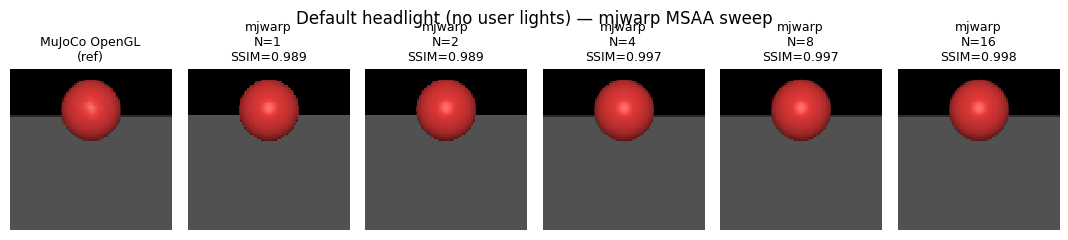

headlight_only
    N     SSIM    meanL1
    1   0.9890    0.0022
    2   0.9893    0.0021
    4   0.9968    0.0009
    8   0.9970    0.0011
   16   0.9975    0.0009


In [3]:
HEADLIGHT_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.3 0.3 0.3" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="128 128"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.6 0.6 0.6 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.2 0.2 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(HEADLIGHT_XML)
print(f"nlight = {mjm.nlight}, headlight.active = {mjm.vis.headlight.active}")
results = msaa_sweep_grid("Default headlight (no user lights) — mjwarp MSAA sweep", mjm, w=96, h=96)
msaa_sweep_table("headlight_only", results)

## 2. Spotlight cutoff & exponent sweep

Sweeping `cutoff` (cone half-angle, degrees) keeps the spotlight aimed
straight down and varies how wide the bright disk on the floor is. Sweeping
`exponent` controls how sharp the falloff is *within* the cone (higher =
tighter hotspot, lower = flat plateau).

Before Phase 1, mjwarp hardcoded `cutoff=18°/32°` and a linear ramp — every
spot light looked identical. Now both parameters drive the render.

Both renderers run with shadows on (the MuJoCo OpenGL default), so the
spherical occluder casts a visible shadow under itself in both panels.

Module render__locals___render_megakernel_03a253df 7294241 load on device 'cpu' took 529.46 ms  (compiled)


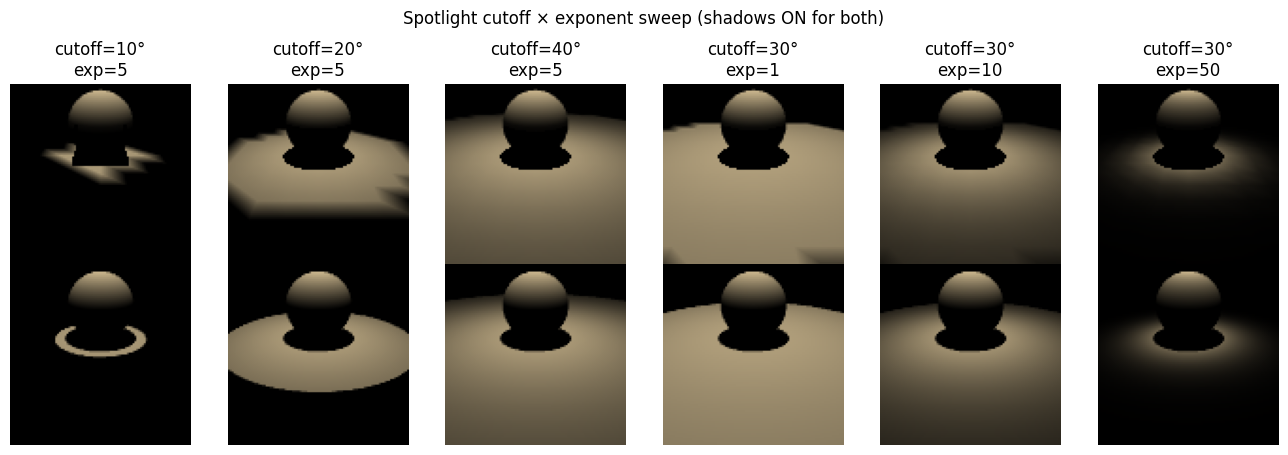

In [4]:
SPOT_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.5 1" resolution="96 96"/>
    <light pos="0 0 2.5" dir="0 0 -1" cutoff="{cutoff}" exponent="{exponent}"
           diffuse="1 0.9 0.7" specular="0 0 0" ambient="0 0 0" attenuation="1 0 0"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.8 0.8 1"/>
  </worldbody>
</mujoco>
"""

sweeps = [(10, 5), (20, 5), (40, 5), (30, 1), (30, 10), (30, 50)]
fig, axes = plt.subplots(2, len(sweeps), figsize=(2.2 * len(sweeps), 4.6))
for col, (cutoff, exponent) in enumerate(sweeps):
  mjm = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=cutoff, exponent=exponent))
  # Both renderers: shadows on, 4x MSAA (mjwarp) / MuJoCo's default MSAA (OpenGL).
  mj = mujoco_render(mjm, 96, 96, use_shadows=True)
  warp = mjwarp_render(mjm, 96, 96, use_shadows=True)
  axes[0, col].imshow(mj)
  axes[0, col].set_title(f"cutoff={cutoff}°\nexp={exponent}")
  axes[0, col].axis("off")
  axes[1, col].imshow(warp)
  axes[1, col].axis("off")
axes[0, 0].set_ylabel("MuJoCo", fontsize=10)
axes[1, 0].set_ylabel("mjwarp", fontsize=10)
fig.suptitle("Spotlight cutoff × exponent sweep (shadows ON for both)")
plt.tight_layout()
plt.show()

### Spotlight: MSAA sweep + shadow OFF vs shadow ON

Two follow-up comparisons on the same scene (`cutoff=20°, exponent=5`):

- **MSAA grid** sweeps `samples_per_pixel` from 1 → 16 with shadows on, so
  you can see how supersampling reduces the cone-boundary stair-step.
- **Shadow toggle** renders the scene in (shadow OFF, OFF) and (shadow ON,
  ON) so the shadow contribution is isolated from the lighting term.

Module render__locals___render_megakernel_658a2891 6a3ca29 load on device 'cpu' took 0.25 ms  (cached)


Module render__locals___render_megakernel_38e05e67 03561d0 load on device 'cpu' took 541.19 ms  (compiled)


Module render__locals___render_megakernel_a5dbf023 741d0d8 load on device 'cpu' took 533.36 ms  (compiled)


Module render__locals___render_megakernel_e8397f34 c937436 load on device 'cpu' took 529.92 ms  (compiled)


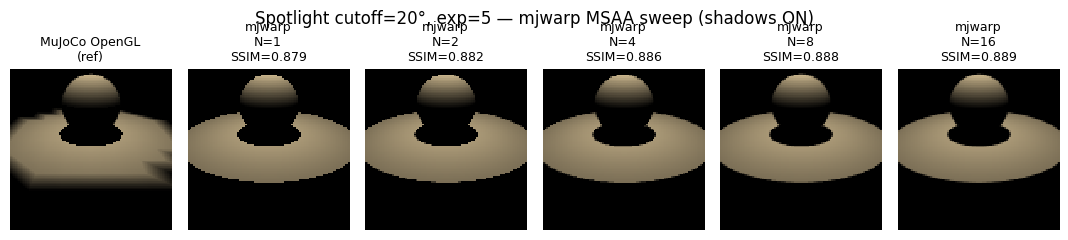

spotlight
    N     SSIM    meanL1
    1   0.8789    0.0207
    2   0.8818    0.0205
    4   0.8863    0.0199
    8   0.8883    0.0197
   16   0.8887    0.0196


In [5]:
mjm_spot_n = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=20, exponent=5))
results = msaa_sweep_grid(
  "Spotlight cutoff=20°, exp=5 — mjwarp MSAA sweep (shadows ON)",
  mjm_spot_n,
  w=96,
  h=96,
  use_shadows=True,
)
msaa_sweep_table("spotlight", results)

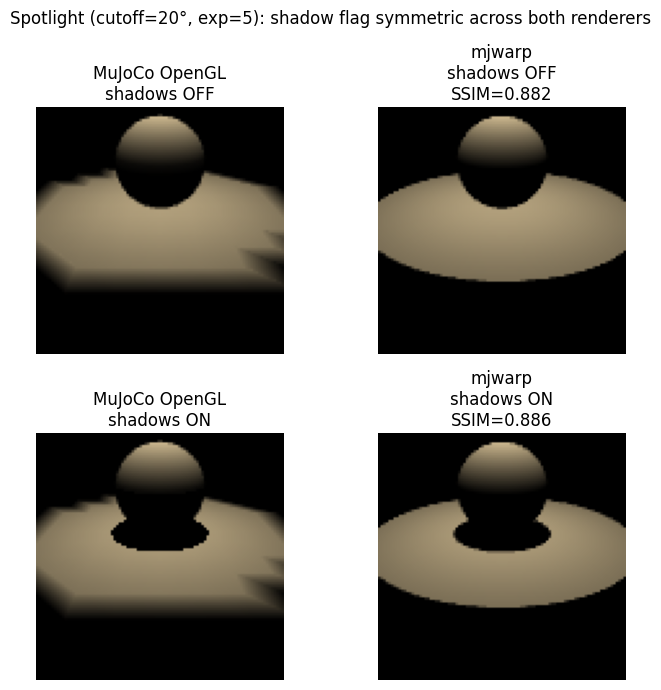

In [6]:
mjm_spot = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=20, exponent=5))

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for row, shadows in enumerate([False, True]):
  mj = mujoco_render(mjm_spot, 96, 96, use_shadows=shadows)
  warp = mjwarp_render(mjm_spot, 96, 96, use_shadows=shadows)
  ssim = ssim_luma(warp, mj)
  axes[row, 0].imshow(mj)
  axes[row, 0].set_title(f"MuJoCo OpenGL\nshadows {'ON' if shadows else 'OFF'}")
  axes[row, 0].axis("off")
  axes[row, 1].imshow(warp)
  axes[row, 1].set_title(f"mjwarp\nshadows {'ON' if shadows else 'OFF'}\nSSIM={ssim:.3f}")
  axes[row, 1].axis("off")
fig.suptitle("Spotlight (cutoff=20°, exp=5): shadow flag symmetric across both renderers")
plt.tight_layout()
plt.show()

## 3. Distance attenuation sweep

OpenGL's three-coefficient attenuation: `atten = 1 / (a0 + a1·d + a2·d²)`.
mjwarp used to hardcode `(1, 0, 0.02)` regardless of the model; now it reads
`light_attenuation` and matches OpenGL's behavior across coefficient choices.

Module render__locals___render_megakernel_564872f9 8bede7c load on device 'cpu' took 537.76 ms  (compiled)


Module render__locals___render_megakernel_82a4e101 34616fa load on device 'cpu' took 528.92 ms  (compiled)


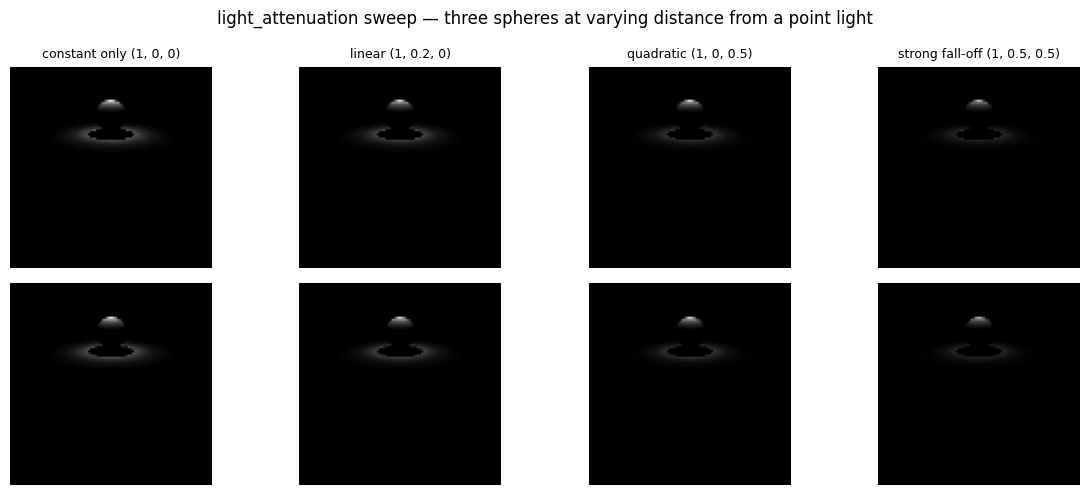

In [7]:
ATTEN_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -4 1" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <light pos="0 0 1" diffuse="1 1 1" specular="0 0 0" ambient="0 0 0" attenuation="{a0} {a1} {a2}"/>
    <geom name="floor" type="plane" size="3 3 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="b1" type="sphere" pos="-1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b2" type="sphere" pos=" 0   0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b3" type="sphere" pos=" 1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

attens = [
  ("constant only (1, 0, 0)", 1.0, 0.0, 0.0),
  ("linear (1, 0.2, 0)", 1.0, 0.2, 0.0),
  ("quadratic (1, 0, 0.5)", 1.0, 0.0, 0.5),
  ("strong fall-off (1, 0.5, 0.5)", 1.0, 0.5, 0.5),
]
fig, axes = plt.subplots(2, len(attens), figsize=(3 * len(attens), 5))
for col, (label, a0, a1, a2) in enumerate(attens):
  mjm = mujoco.MjModel.from_xml_string(ATTEN_XML.format(a0=a0, a1=a1, a2=a2))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(label, fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("light_attenuation sweep — three spheres at varying distance from a point light")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_89ea328a d9b31ad load on device 'cpu' took 534.99 ms  (compiled)


Module render__locals___render_megakernel_705677ca 3d4fc30 load on device 'cpu' took 547.17 ms  (compiled)


Module render__locals___render_megakernel_c42372ef 075b513 load on device 'cpu' took 530.93 ms  (compiled)


Module render__locals___render_megakernel_e764f787 49b879d load on device 'cpu' took 535.86 ms  (compiled)


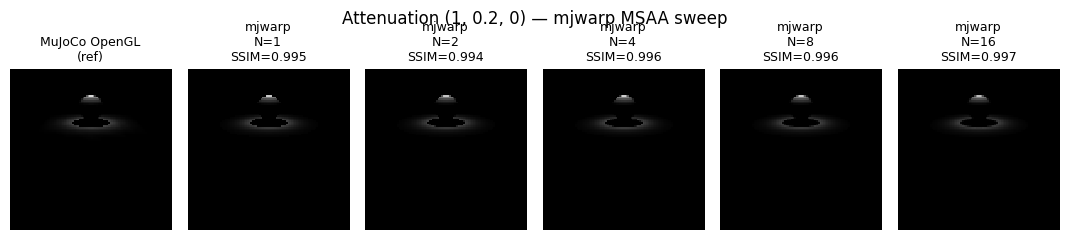

attenuation
    N     SSIM    meanL1
    1   0.9946    0.0006
    2   0.9943    0.0007
    4   0.9960    0.0006
    8   0.9961    0.0007
   16   0.9965    0.0006


In [8]:
mjm_atten_n = mujoco.MjModel.from_xml_string(ATTEN_XML.format(a0=1.0, a1=0.2, a2=0.0))
results = msaa_sweep_grid(
  "Attenuation (1, 0.2, 0) — mjwarp MSAA sweep",
  mjm_atten_n,
  w=96,
  h=96,
)
msaa_sweep_table("attenuation", results)

## 4. Per-light color

Two directional lights of distinct color (red and blue) should yield a
purple cross-illumination region in the middle and pure red / blue lobes on
the sides. Before Phase 1, all lights contributed identical white in
mjwarp.

Module render__locals___render_megakernel_9dcf7c1e 02bbbfa load on device 'cpu' took 0.23 ms  (cached)


Module render__locals___render_megakernel_d3c838b6 815a5e1 load on device 'cpu' took 572.03 ms  (compiled)


Module render__locals___render_megakernel_74bfbf95 1868810 load on device 'cpu' took 563.43 ms  (compiled)


Module render__locals___render_megakernel_1f52c2c1 228fe0e load on device 'cpu' took 574.95 ms  (compiled)


Module render__locals___render_megakernel_e023d21c 0e8d65c load on device 'cpu' took 557.47 ms  (compiled)


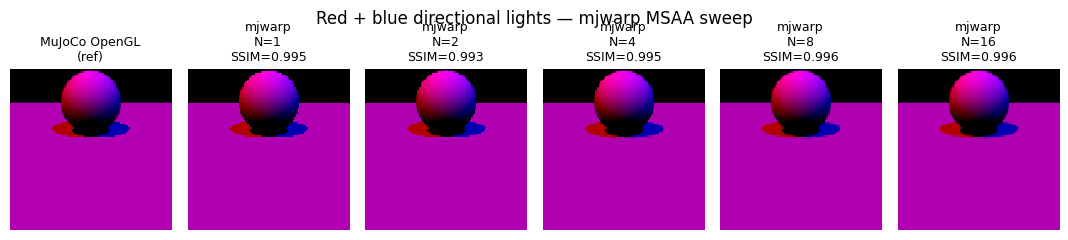

two_lights
    N     SSIM    meanL1
    1   0.9946    0.0038
    2   0.9928    0.0039
    4   0.9949    0.0039
    8   0.9960    0.0031
   16   0.9964    0.0031


In [9]:
TWO_LIGHTS_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="128 128"/>
    <light pos="-1 -1 2" dir="0.4 0.4 -1" directional="true" diffuse="1 0 0"
           specular="0 0 0" ambient="0 0 0"/>
    <light pos=" 1 -1 2" dir="-0.4 0.4 -1" directional="true" diffuse="0 0 1"
           specular="0 0 0" ambient="0 0 0"/>
    <geom type="plane" size="2 2 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(TWO_LIGHTS_XML)
results = msaa_sweep_grid("Red + blue directional lights — mjwarp MSAA sweep", mjm, w=96, h=96)
msaa_sweep_table("two_lights", results)

## 5. Specular highlights (Phong)

Sweeping `shininess` (stored in [0, 1], mapped to OpenGL exponent in
[0, 128]) controls the tightness of the highlight: low shininess = broad
soft highlight, high shininess = small intense hotspot.

Sweeping `specular` controls the highlight intensity.

Module render__locals___render_megakernel_fcaec8f8 41e1c6e load on device 'cpu' took 468.34 ms  (compiled)


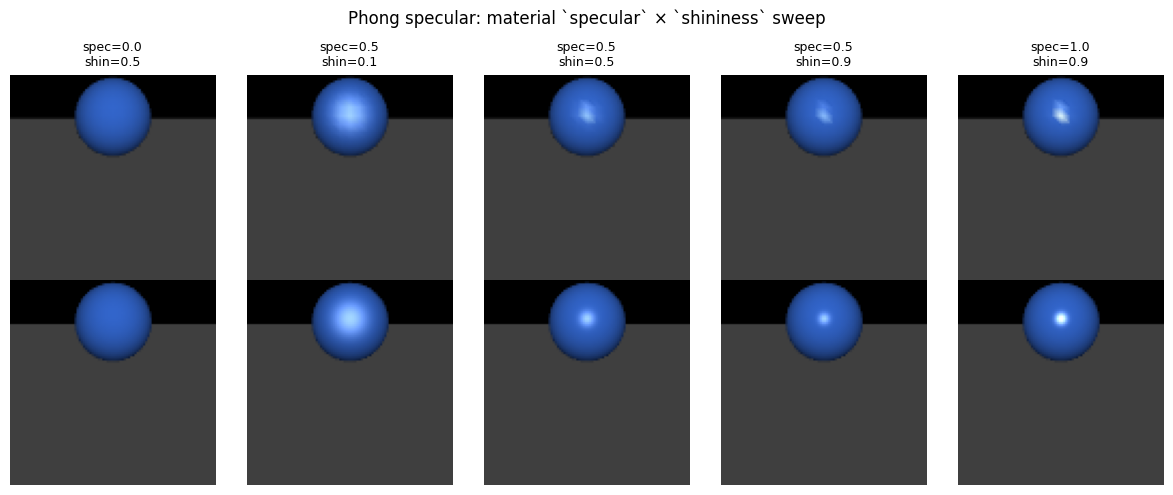

In [10]:
SPECULAR_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.9 0.9 0.9"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="m" specular="{spec}" shininess="{shin}" rgba="0.2 0.4 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.5 0.5 0.5 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="m"/>
  </worldbody>
</mujoco>
"""

specs = [(0.0, 0.5), (0.5, 0.1), (0.5, 0.5), (0.5, 0.9), (1.0, 0.9)]
fig, axes = plt.subplots(2, len(specs), figsize=(2.4 * len(specs), 5))
for col, (spec, shin) in enumerate(specs):
  mjm = mujoco.MjModel.from_xml_string(SPECULAR_XML.format(spec=spec, shin=shin))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"spec={spec}\nshin={shin}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("Phong specular: material `specular` × `shininess` sweep")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_e9f52ce6 5f04a2d load on device 'cpu' took 0.25 ms  (cached)


Module render__locals___render_megakernel_d3111602 76a0956 load on device 'cpu' took 479.24 ms  (compiled)


Module render__locals___render_megakernel_806962de 8833b8e load on device 'cpu' took 471.50 ms  (compiled)


Module render__locals___render_megakernel_1edb882e a3ddfd3 load on device 'cpu' took 479.44 ms  (compiled)


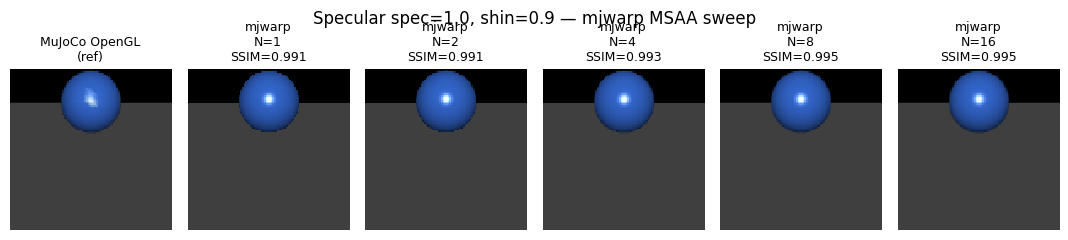

specular
    N     SSIM    meanL1
    1   0.9914    0.0019
    2   0.9908    0.0020
    4   0.9933    0.0018
    8   0.9949    0.0014
   16   0.9954    0.0013


In [11]:
mjm_spec_n = mujoco.MjModel.from_xml_string(SPECULAR_XML.format(spec=1.0, shin=0.9))
results = msaa_sweep_grid(
  "Specular spec=1.0, shin=0.9 — mjwarp MSAA sweep",
  mjm_spec_n,
  w=96,
  h=96,
)
msaa_sweep_table("specular", results)

## 6. Material emission

`mat_emission` is a scalar self-illumination factor. With no lights in the
scene and emission > 0, the geom should still be visible (and tinted by its
diffuse color).

Module render__locals___render_megakernel_64b6676b 8f5a254 load on device 'cpu' took 450.00 ms  (compiled)


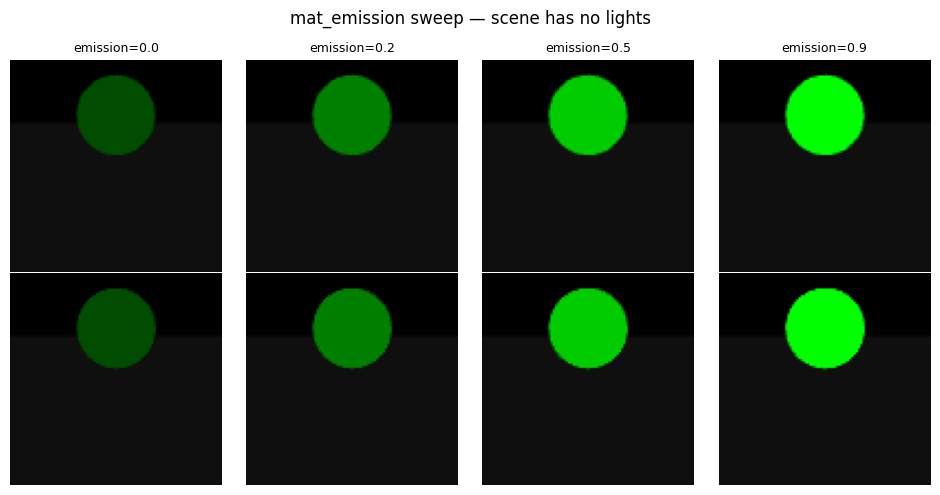

In [12]:
EMISSION_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="glow" emission="{emis}" rgba="0 1 0 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.2 0.2 0.2 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="glow"/>
  </worldbody>
</mujoco>
"""

emissions = [0.0, 0.2, 0.5, 0.9]
fig, axes = plt.subplots(2, len(emissions), figsize=(2.4 * len(emissions), 5))
for col, emis in enumerate(emissions):
  mjm = mujoco.MjModel.from_xml_string(EMISSION_XML.format(emis=emis))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"emission={emis}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("mat_emission sweep — scene has no lights")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_36ed8a9d 126a00a load on device 'cpu' took 0.23 ms  (cached)


Module render__locals___render_megakernel_31befb05 08c3639 load on device 'cpu' took 445.87 ms  (compiled)


Module render__locals___render_megakernel_1b15da31 52d74c9 load on device 'cpu' took 449.18 ms  (compiled)


Module render__locals___render_megakernel_277e9b5e c07d543 load on device 'cpu' took 442.90 ms  (compiled)


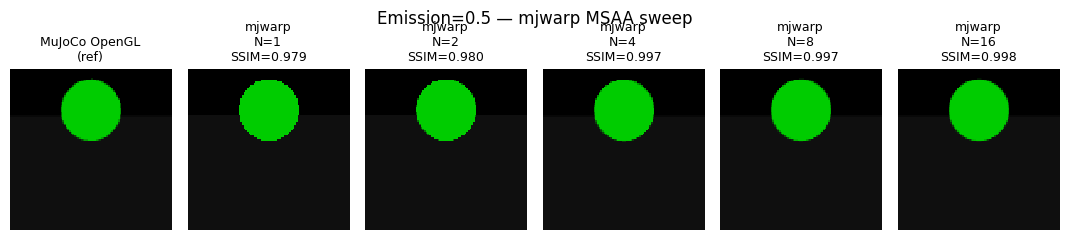

emission
    N     SSIM    meanL1
    1   0.9794    0.0010
    2   0.9801    0.0009
    4   0.9965    0.0005
    8   0.9969    0.0004
   16   0.9979    0.0004


In [13]:
mjm_emis_n = mujoco.MjModel.from_xml_string(EMISSION_XML.format(emis=0.5))
results = msaa_sweep_grid("Emission=0.5 — mjwarp MSAA sweep", mjm_emis_n, w=96, h=96)
msaa_sweep_table("emission", results)

## 7. Shadows

mjwarp's shadow rays produce geometrically exact, aliasing-free shadow
boundaries — strictly better than OpenGL shadow maps but not pixel-identical.
Phase 1 also changed mjwarp's shadow visibility from `0.3` (partial) to `0.0`
(binary), matching OpenGL.

The MuJoCo OpenGL renderer turns shadows on by default
(`scene.flags[mjRND_SHADOW] == 1`); mjwarp's `create_render_context` defaults
to `use_shadows=False` for performance. To make the comparison apples-to-
apples, the helpers in this notebook default `use_shadows=True` on both
backends and let you toggle them symmetrically.

The grid below shows the same scene rendered in **both renderers with
shadows OFF**, then **both with shadows ON**, so the renderer pair stays
symmetric and the shadow effect is isolated.

Module render__locals___render_megakernel_7af39a23 0dcb1f4 load on device 'cpu' took 531.69 ms  (compiled)


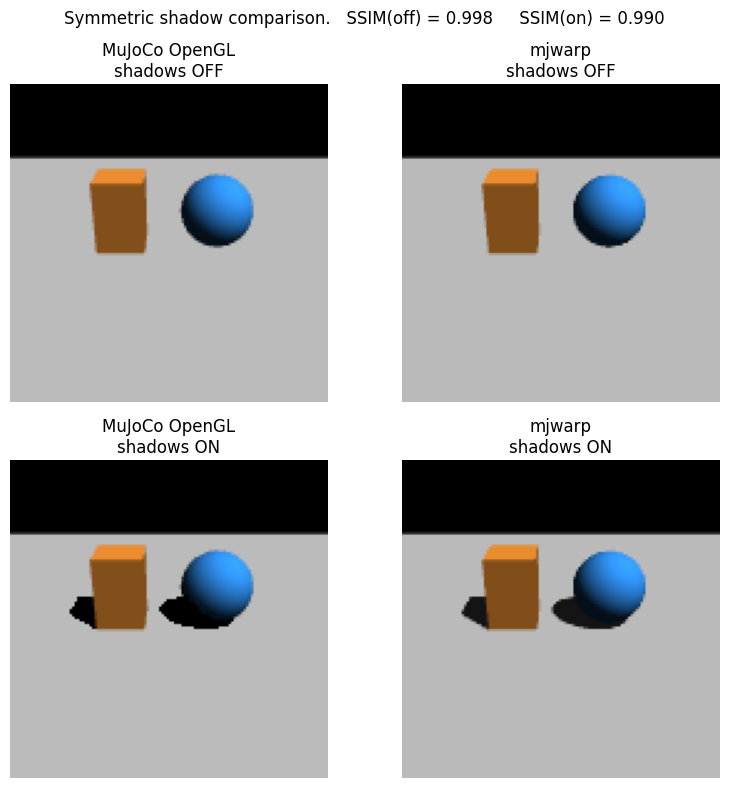

In [14]:
SHADOW_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
    <quality shadowsize="2048"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -3 1.5" xyaxes="1 0 0 0 0.5 1" resolution="128 128"/>
    <light pos="2 -2 4" dir="-0.5 0.5 -1" directional="true" castshadow="true"
           diffuse="1 1 1" specular="0 0 0" ambient="0.1 0.1 0.1"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box" pos="-0.4 0 0.3" size="0.2 0.2 0.3" rgba="1 0.6 0.2 1"/>
    <geom type="sphere" pos="0.4 0 0.3" size="0.3" rgba="0.2 0.6 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(SHADOW_XML)

# Render both backends in both shadow modes (off, off) and (on, on) so the
# comparison stays symmetric — turning shadows on in only one of the two
# renderers would create a false discrepancy in regions occluded by geometry.
mj_off = mujoco_render(mjm, 128, 128, use_shadows=False)
warp_off = mjwarp_render(mjm, 128, 128, use_shadows=False)
mj_on = mujoco_render(mjm, 128, 128, use_shadows=True)
warp_on = mjwarp_render(mjm, 128, 128, use_shadows=True)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(mj_off)
axes[0, 0].set_title("MuJoCo OpenGL\nshadows OFF")
axes[0, 0].axis("off")
axes[0, 1].imshow(warp_off)
axes[0, 1].set_title("mjwarp\nshadows OFF")
axes[0, 1].axis("off")
axes[1, 0].imshow(mj_on)
axes[1, 0].set_title("MuJoCo OpenGL\nshadows ON")
axes[1, 0].axis("off")
axes[1, 1].imshow(warp_on)
axes[1, 1].set_title("mjwarp\nshadows ON")
axes[1, 1].axis("off")

ssim_off = ssim_luma(warp_off, mj_off)
ssim_on = ssim_luma(warp_on, mj_on)
fig.suptitle(
  "Symmetric shadow comparison.   "
  f"SSIM(off) = {ssim_off:.3f}     SSIM(on) = {ssim_on:.3f}"
)
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_9030dbb8 f43aa65 load on device 'cpu' took 527.77 ms  (compiled)


Module render__locals___render_megakernel_1ceee46a 5c4752a load on device 'cpu' took 540.72 ms  (compiled)


Module render__locals___render_megakernel_e0cd7fb7 28aa985 load on device 'cpu' took 525.22 ms  (compiled)


Module render__locals___render_megakernel_e2bd3119 71fd306 load on device 'cpu' took 529.47 ms  (compiled)


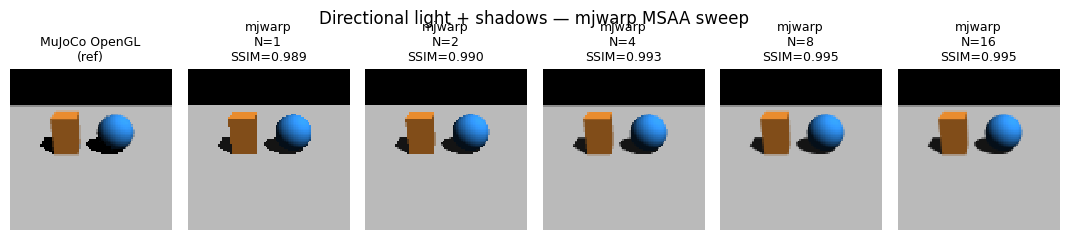

shadows
    N     SSIM    meanL1
    1   0.9890    0.0077
    2   0.9898    0.0078
    4   0.9934    0.0056
    8   0.9947    0.0056
   16   0.9952    0.0055


In [15]:
mjm_shadow_n = mujoco.MjModel.from_xml_string(SHADOW_XML)
results = msaa_sweep_grid(
  "Directional light + shadows — mjwarp MSAA sweep",
  mjm_shadow_n,
  w=96,
  h=96,
  use_shadows=True,
)
msaa_sweep_table("shadows", results)

## 8. Supersample anti-aliasing (MSAA)

A single ray per pixel produces visible stair-stepping along geom
silhouettes. `create_render_context(samples_per_pixel=N)` fires N jittered
rays per pixel using a Halton(2, 3) low-discrepancy pattern and averages the
results, producing smooth silhouettes at proportionally higher shading cost.

The sweep below uses a low resolution (32×32) so the aliasing at N=1 is
obvious, then shows N=4 and N=16. The MuJoCo OpenGL reference is on the left
for comparison.

Module render__locals___render_megakernel_c2fea594 00e8e26 load on device 'cpu' took 465.13 ms  (compiled)


Module render__locals___render_megakernel_c96e7840 13e14dc load on device 'cpu' took 465.25 ms  (compiled)


Module render__locals___render_megakernel_121dff9a a9f386a load on device 'cpu' took 473.68 ms  (compiled)


Module render__locals___render_megakernel_7b6fa9f8 03fcdc3 load on device 'cpu' took 471.52 ms  (compiled)


Module render__locals___render_megakernel_43091d12 b428cdd load on device 'cpu' took 479.03 ms  (compiled)


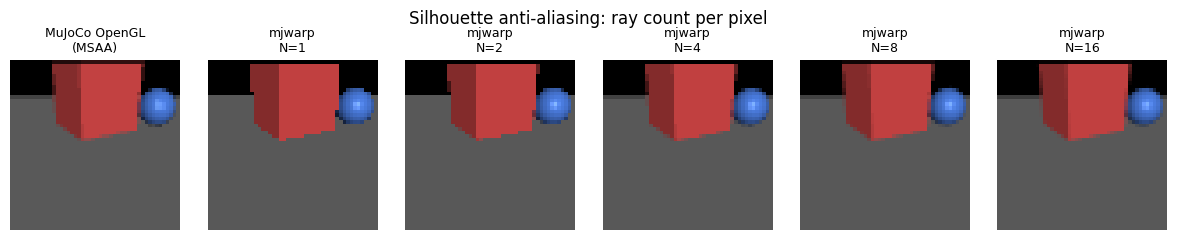

In [16]:
MSAA_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="48 48"/>
    <geom type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom type="box" pos="0 0 0.3" size="0.3 0.3 0.3" euler="0 0 30" rgba="0.9 0.3 0.3 1"/>
    <geom type="sphere" pos="0.6 0 0.2" size="0.18" rgba="0.3 0.5 0.9 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(MSAA_XML)
mj = mujoco_render(mjm, 48, 48)

samples = [1, 2, 4, 8, 16]
fig, axes = plt.subplots(1, len(samples) + 1, figsize=(2.0 * (len(samples) + 1), 2.4))
axes[0].imshow(mj, interpolation="nearest")
axes[0].set_title("MuJoCo OpenGL\n(MSAA)", fontsize=9)
axes[0].axis("off")
for col, n in enumerate(samples, start=1):
  img = mjwarp_render(mjm, 48, 48, samples_per_pixel=n)
  axes[col].imshow(img, interpolation="nearest")
  axes[col].set_title(f"mjwarp\nN={n}", fontsize=9)
  axes[col].axis("off")
fig.suptitle("Silhouette anti-aliasing: ray count per pixel")
plt.tight_layout()
plt.show()

### MSAA cost

MSAA scales linearly with `samples_per_pixel` since each sample re-casts a
primary ray and re-evaluates the full shading chain. Background pixels are
cheaper than hit pixels.

In [17]:
def bench_msaa(mjm, w, h, n_samples):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(mjm, cam_res=(w, h), render_rgb=True, samples_per_pixel=n_samples)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  # warm up to compile the kernel for this N
  for _ in range(2):
    step()
  ts = []
  for _ in range(5):
    t0 = time.perf_counter()
    step()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


mjm_bench_msaa = mujoco.MjModel.from_xml_string(MSAA_XML)
ns = [1, 2, 4, 8, 16]
times = [bench_msaa(mjm_bench_msaa, 128, 128, n) for n in ns]
print(f"{'N':>3s}  {'time (ms)':>10s}  {'cost/sample (ms)':>17s}")
for n, t in zip(ns, times):
  print(f"{n:>3d}  {t * 1000:>10.2f}  {t * 1000 / n:>17.3f}")

  N   time (ms)   cost/sample (ms)
  1       12.09             12.095
  2       12.84              6.420
  4       14.30              3.576
  8       17.15              2.144
 16       22.79              1.424


## 9. SSIM summary across all canonical fixtures

Aggregate parity numbers for the same fixtures used in
`render_parity_test.py`, with mjwarp evaluated at each `samples_per_pixel`
in the canonical MSAA sweep. The N=1 column reflects the renderer's
production default (no MSAA, single ray per pixel); higher Ns show how
much of the residual gap to MuJoCo OpenGL comes from aliasing alone.

In [18]:
from mujoco_warp._src.render_parity_test import (
  _FIXTURE_EMISSION,
  _FIXTURE_HEADLIGHT_ONLY,
  _FIXTURE_SPECULAR,
  _FIXTURE_SPOTLIGHT,
  _FIXTURE_TWO_LIGHTS,
)

fixtures = [
  ("headlight_only", _FIXTURE_HEADLIGHT_ONLY),
  ("spotlight", _FIXTURE_SPOTLIGHT),
  ("specular", _FIXTURE_SPECULAR),
  ("two_lights", _FIXTURE_TWO_LIGHTS),
  ("emission", _FIXTURE_EMISSION),
]

# fixture -> {N: (ssim, meanL1)}
ssim_table = {}
for name, xml in fixtures:
  mjm = mujoco.MjModel.from_xml_string(xml)
  mj_rgb = mujoco_render(mjm, 64, 64)
  by_n = {}
  for n in MSAA_NS:
    warp_rgb = mjwarp_render(mjm, 64, 64, samples_per_pixel=n)
    by_n[n] = (ssim_luma(warp_rgb, mj_rgb), mean_l1(warp_rgb, mj_rgb))
  ssim_table[name] = by_n

header_n = "  ".join(f"N={n:<2d}" for n in MSAA_NS)
print(f"SSIM vs MuJoCo OpenGL (higher is better):")
print(f"  {'fixture':<18s}  {header_n}")
for name, by_n in ssim_table.items():
  cells = "  ".join(f"{by_n[n][0]:>5.3f}" for n in MSAA_NS)
  print(f"  {name:<18s}  {cells}")

print()
print(f"mean L1 vs MuJoCo OpenGL (lower is better):")
print(f"  {'fixture':<18s}  {header_n}")
for name, by_n in ssim_table.items():
  cells = "  ".join(f"{by_n[n][1]:>5.3f}" for n in MSAA_NS)
  print(f"  {name:<18s}  {cells}")

SSIM vs MuJoCo OpenGL (higher is better):
  fixture             N=1   N=2   N=4   N=8   N=16
  headlight_only      0.991  0.991  0.996  0.996  0.997
  spotlight           0.917  0.921  0.928  0.931  0.932
  specular            0.986  0.988  0.992  0.994  0.995
  two_lights          0.994  0.993  0.995  0.997  0.997
  emission            0.994  0.995  0.997  0.996  0.997

mean L1 vs MuJoCo OpenGL (lower is better):
  fixture             N=1   N=2   N=4   N=8   N=16
  headlight_only      0.002  0.002  0.001  0.001  0.001
  spotlight           0.016  0.016  0.015  0.015  0.015
  specular            0.002  0.003  0.002  0.002  0.002
  two_lights          0.005  0.005  0.005  0.004  0.004
  emission            0.002  0.002  0.001  0.001  0.001


## 10. Performance benchmarks

Comparing the two renderers on the same scene at increasing image
resolutions, world counts, and `samples_per_pixel` values. The MSAA
dimension is added to each existing benchmark so the cost / quality
tradeoff is visible across all three perf axes.

Each measurement is the median of `n_repeats` runs after a warmup, so the
first kernel compile is excluded.

> On CPU-only Warp builds the multi-world numbers are not representative of
> production GPU throughput; they're shown to verify the kernel scales
> linearly with world count rather than catastrophically.

In [19]:
BENCH_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.7 0.7 0.7" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="shiny" specular="0.7" shininess="0.6" rgba="0.4 0.5 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="64 64"/>
    <light pos="1 -1 2" dir="-0.4 0.5 -1" diffuse="0.8 0.8 0.7" specular="0.5 0.5 0.5"
           ambient="0.05 0.05 0.05" attenuation="1 0 0" castshadow="false"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box"     pos="-0.6 0 0.25" size="0.2 0.2 0.25" material="shiny"/>
    <geom type="sphere"  pos=" 0   0 0.30" size="0.30" material="shiny"/>
    <geom type="capsule" pos=" 0.6 0 0.30" size="0.15 0.15" material="shiny"/>
  </worldbody>
</mujoco>
"""


def time_call(fn, n_warmup: int = 2, n_repeats: int = 5) -> float:
  for _ in range(n_warmup):
    fn()
  ts = []
  for _ in range(n_repeats):
    t0 = time.perf_counter()
    fn()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


def bench_mujoco(mjm, w, h, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    def step():
      r.update_scene(mjd, camera=0)
      r.render()
    return time_call(step, n_warmup, n_repeats)


def bench_mjwarp(mjm, w, h, nworld=1, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=False)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  return time_call(step, n_warmup, n_repeats)

### Resolution sweep — single-world, MSAA sweep

`mujoco.Renderer` only renders one scene at a time. mjwarp's per-world cost
is dominated by `total_rays = W·H · samples_per_pixel` per camera, so we
expect roughly linear growth with pixel count and with sample count. The
chart plots one line per `N ∈ MSAA_NS` so you can read the cost of both
dimensions at once.

Module render__locals___render_megakernel_7aa53170 969837a load on device 'cpu' took 0.25 ms  (cached)


Module render__locals___render_megakernel_043ec969 a763710 load on device 'cpu' took 547.77 ms  (compiled)


Module render__locals___render_megakernel_ce087d5a 1c1060f load on device 'cpu' took 545.28 ms  (compiled)


Module render__locals___render_megakernel_0bd1cff5 293fc6a load on device 'cpu' took 586.50 ms  (compiled)


Module render__locals___render_megakernel_4c0f45ae cd73276 load on device 'cpu' took 574.55 ms  (compiled)


backend                   32²    64²    96²   128²   192²   256²
  mujoco.Renderer        0.67   0.36   0.31   0.32   0.38   0.40
  mjwarp N=1            10.91  11.45  12.04  12.79  15.58  19.32
  mjwarp N=2            11.06  11.33  12.68  14.16  19.00  24.67
  mjwarp N=4            11.01  12.23  13.91  17.22  25.19  36.17
  mjwarp N=8            11.69  13.90  18.34  22.68  36.56  58.63
  mjwarp N=16           12.90  16.68  27.62  40.76  63.42  101.10


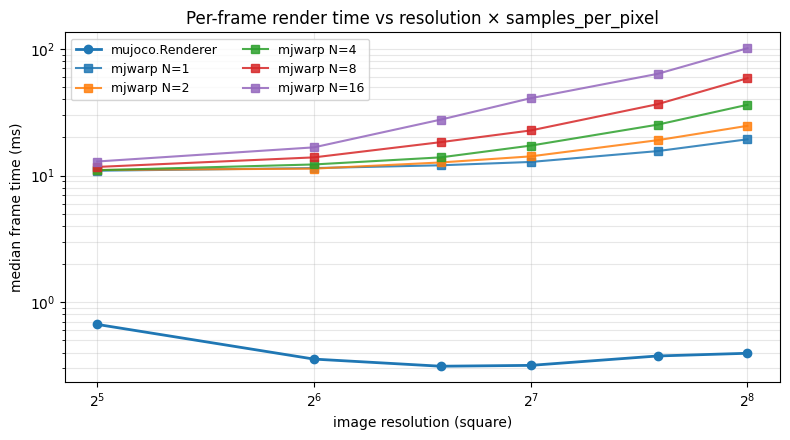

In [20]:
def bench_mjwarp_n(mjm, w, h, nworld=1, samples_per_pixel=1, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(
    mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=False, samples_per_pixel=samples_per_pixel
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step, n_warmup, n_repeats)


mjm_bench = mujoco.MjModel.from_xml_string(BENCH_XML)
resolutions = [32, 64, 96, 128, 192, 256]

mj_times = [bench_mujoco(mjm_bench, r, r) for r in resolutions]
warp_times_by_n = {n: [bench_mjwarp_n(mjm_bench, r, r, nworld=1, samples_per_pixel=n) for r in resolutions] for n in MSAA_NS}

header_res = "  ".join(f"{r:>4d}²" for r in resolutions)
print(f"{'backend':<22s}  {header_res}")
mj_row = "  ".join(f"{t * 1000:>5.2f}" for t in mj_times)
print(f"  {'mujoco.Renderer':<20s}  {mj_row}")
for n in MSAA_NS:
  row = "  ".join(f"{t * 1000:>5.2f}" for t in warp_times_by_n[n])
  print(f"  {'mjwarp N=' + str(n):<20s}  {row}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(resolutions, np.array(mj_times) * 1000, "o-", label="mujoco.Renderer", color="C0", linewidth=2)
for n in MSAA_NS:
  ax.plot(resolutions, np.array(warp_times_by_n[n]) * 1000, "s-", label=f"mjwarp N={n}", alpha=0.85)
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("median frame time (ms)")
ax.set_title("Per-frame render time vs resolution × samples_per_pixel")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

### World-count scaling — mjwarp only, with MSAA dimension

`mujoco.Renderer` can't batch worlds, so this scaling chart only applies to
mjwarp. We expect throughput in frames/sec to grow with world count on a
healthy GPU (the kernel parallelizes over both worlds and rays), bottoming
out only when the device saturates.

One line per `samples_per_pixel`. Adjust `world_counts` based on your
hardware. On CPU we cap at small values to keep the notebook responsive.

per-world cost (ms) at 64×64:
  samples     w=   1  w=   4  w=  16  w=  64
  N=1         12.125   3.481   1.306   0.759
  N=2         12.247   3.606   1.607   1.090
  N=4         12.423   4.445   2.253   1.704
  N=8         13.787   5.529   3.617   3.060
  N=16        17.334   8.298   6.114   5.725


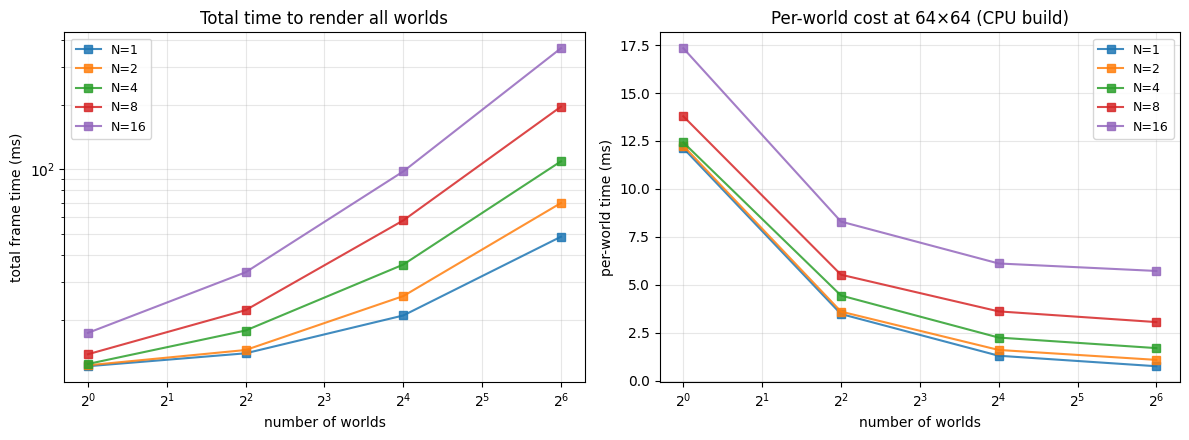

In [21]:
has_cuda = wp.get_cuda_device_count() > 0
if has_cuda:
  world_counts = [1, 4, 16, 64, 256, 1024]
else:
  world_counts = [1, 4, 16, 64]

cam_w = cam_h = 64

# frames[N] = list of total times (one per nworld in world_counts)
frame_times_by_n = {n: [bench_mjwarp_n(mjm_bench, cam_w, cam_h, nworld=w, samples_per_pixel=n) for w in world_counts] for n in MSAA_NS}

header_world = "  ".join(f"w={w:>4d}" for w in world_counts)
print(f"per-world cost (ms) at {cam_w}×{cam_h}:")
print(f"  {'samples':<10s}  {header_world}")
for n in MSAA_NS:
  per_world = [t * 1000 / w for t, w in zip(frame_times_by_n[n], world_counts)]
  row = "  ".join(f"{v:>6.3f}" for v in per_world)
  print(f"  {'N=' + str(n):<10s}  {row}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for n in MSAA_NS:
  axes[0].plot(world_counts, np.array(frame_times_by_n[n]) * 1000, "s-", label=f"N={n}", alpha=0.85)
axes[0].set_xlabel("number of worlds")
axes[0].set_ylabel("total frame time (ms)")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_title("Total time to render all worlds")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=9)

for n in MSAA_NS:
  per_world = np.array(frame_times_by_n[n]) * 1000 / np.array(world_counts)
  axes[1].plot(world_counts, per_world, "s-", label=f"N={n}", alpha=0.85)
axes[1].set_xlabel("number of worlds")
axes[1].set_ylabel("per-world time (ms)")
axes[1].set_xscale("log", base=2)
axes[1].set_title(f"Per-world cost at {cam_w}×{cam_h} ({'CUDA' if has_cuda else 'CPU'} build)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Shadow cost × MSAA

Enabling shadows roughly doubles per-pixel work because every lit pixel
casts an additional shadow ray per active light. With MSAA, that extra
shadow ray is fired per sub-pixel sample, so the shadow overhead also
scales with `samples_per_pixel`. This cell quantifies both axes on the
benchmark scene.

res         N    off (ms)   on (ms)  on/off


  64x64    N=1     11.83    11.92   1.01x


  64x64    N=2     12.23    12.23   1.00x
  64x64    N=4     12.77    12.98   1.02x


  64x64    N=8     13.55    14.65   1.08x


  64x64    N=16    16.51    18.48   1.12x
 128x128   N=1     12.88    13.51   1.05x


...

 256x256   N=1     20.06    22.11   1.10x


 256x256   N=2     24.61    29.49   1.20x


 256x256   N=4     35.01    44.91   1.28x


 256x256   N=8     56.57    73.86   1.31x


 256x256   N=16    97.63   132.09   1.35x


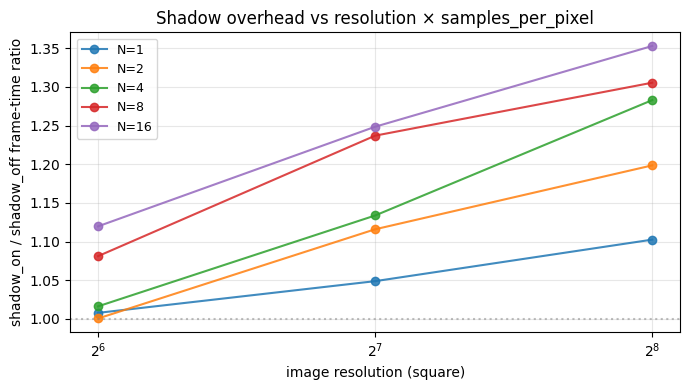

In [22]:
SHADOW_BENCH_XML = BENCH_XML.replace('castshadow="false"', 'castshadow="true"')
mjm_shadow = mujoco.MjModel.from_xml_string(SHADOW_BENCH_XML)


def bench_mjwarp_shadows(mjm, w, h, use_shadows: bool, samples_per_pixel: int = 1, nworld: int = 1):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(
    mjm,
    nworld=nworld,
    cam_res=(w, h),
    render_rgb=True,
    use_shadows=use_shadows,
    samples_per_pixel=samples_per_pixel,
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step)


shadow_res = [64, 128, 256]
ratios = {n: [] for n in MSAA_NS}
print(f"{'res':<10s}  {'N':<3s}  {'off (ms)':>8s}  {'on (ms)':>8s}  {'on/off':>6s}")
for r in shadow_res:
  for n in MSAA_NS:
    t_off = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=False, samples_per_pixel=n)
    t_on = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=True, samples_per_pixel=n)
    ratios[n].append(t_on / t_off)
    print(f"{r:>4d}x{r:<4d}  N={n:<2d}  {t_off * 1000:>7.2f}  {t_on * 1000:>7.2f}  {t_on / t_off:>5.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
for n in MSAA_NS:
  ax.plot(shadow_res, ratios[n], "o-", label=f"N={n}", alpha=0.85)
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("shadow_on / shadow_off frame-time ratio")
ax.set_title("Shadow overhead vs resolution × samples_per_pixel")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", alpha=0.3)
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Per-feature opt-out flags

Each Phase 1 lighting feature can be disabled at render-context creation
time. The flags are `wp.static` inside the kernel, so opting out genuinely
removes the cost at compile time — not a runtime branch.

  - `enable_headlight=False` skips injecting `vis.headlight`.
  - `enable_specular=False` drops the Phong specular term.
  - `enable_emission=False` drops the `mat_emission` term.
  - `enable_per_light_ambient=False` skips summing `light_ambient` per pixel.

This section measures each flag's cost on the benchmark scene at 128×128
with one user light. Defaults match MuJoCo OpenGL behavior; users who don't
need a given feature (e.g. depth-only workflows, or scenes with matte
materials) can opt out for measurable speedups.

config                                 time (ms)   Δ vs all-on
  all on (default)                        12.95             -


Module render__locals___render_megakernel_32bc9e5d ccc66dc load on device 'cpu' took 547.09 ms  (compiled)
  enable_headlight=False                  12.50         -0.45


Module render__locals___render_megakernel_2da68e5e 6ceaa64 load on device 'cpu' took 542.53 ms  (compiled)
  enable_specular=False                   13.03         +0.08


Module render__locals___render_megakernel_5cbc4db1 7c8b1f2 load on device 'cpu' took 555.81 ms  (compiled)
  enable_emission=False                   13.02         +0.08


Module render__locals___render_megakernel_7e8c7956 c4f01e8 load on device 'cpu' took 547.10 ms  (compiled)
  enable_per_light_ambient=False          13.04         +0.10
Module render__locals___render_megakernel_9b8211b1 9dd668a load on device 'cpu' took 0.22 ms  (cached)
  all four perf knobs off                 12.27         -0.68


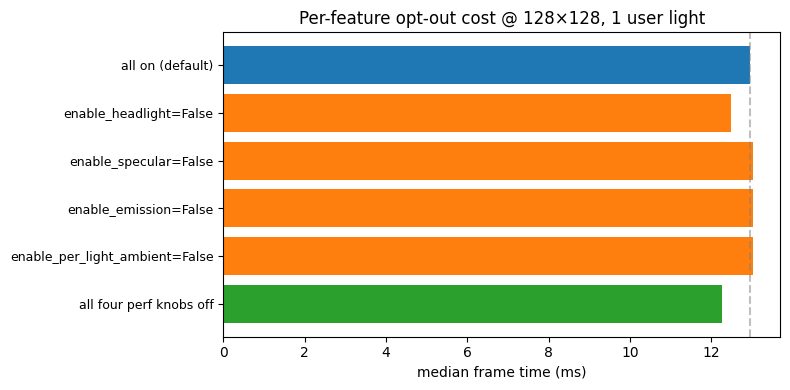

In [23]:
# A scene with one shiny material + emission + ambient on the user light so
# every flag has something to disable. Same geometry as the perf bench, but
# with mat_emission != 0 and light_ambient != 0.
OPTOUT_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.7 0.7 0.7" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="shiny" specular="0.7" shininess="0.6" emission="0.15" rgba="0.4 0.5 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="128 128"/>
    <light pos="1 -1 2" dir="-0.4 0.5 -1" diffuse="0.8 0.8 0.7" specular="0.5 0.5 0.5"
           ambient="0.15 0.15 0.15" attenuation="1 0 0" castshadow="false"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box"     pos="-0.6 0 0.25" size="0.2 0.2 0.25" material="shiny"/>
    <geom type="sphere"  pos=" 0   0 0.30" size="0.30" material="shiny"/>
    <geom type="capsule" pos=" 0.6 0 0.30" size="0.15 0.15" material="shiny"/>
  </worldbody>
</mujoco>
"""
mjm_optout = mujoco.MjModel.from_xml_string(OPTOUT_XML)


def bench_with_flags(**flag_kwargs) -> float:
  mjd = mujoco.MjData(mjm_optout)
  mujoco.mj_forward(mjm_optout, mjd)
  m = mjw.put_model(mjm_optout)
  d = mjw.put_data(mjm_optout, mjd)
  rc = mjw.create_render_context(
    mjm_optout,
    cam_res=(128, 128),
    render_rgb=True,
    use_shadows=False,
    samples_per_pixel=1,
    **flag_kwargs,
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step)


configs = [
  ("all on (default)", {}),
  ("enable_headlight=False", {"enable_headlight": False}),
  ("enable_specular=False", {"enable_specular": False}),
  ("enable_emission=False", {"enable_emission": False}),
  ("enable_per_light_ambient=False", {"enable_per_light_ambient": False}),
  (
    "all four perf knobs off",
    {
      "enable_headlight": False,
      "enable_specular": False,
      "enable_emission": False,
      "enable_per_light_ambient": False,
    },
  ),
]

baseline_t = bench_with_flags()
print(f"{'config':<36s}  {'time (ms)':>10s}  {'Δ vs all-on':>12s}")
print(f"  {'all on (default)':<34s}  {baseline_t * 1000:>9.2f}   {'-':>11s}")
rows = [("all on (default)", baseline_t)]
for label, kwargs in configs[1:]:
  t_ = bench_with_flags(**kwargs)
  rows.append((label, t_))
  delta = (t_ - baseline_t) * 1000
  print(f"  {label:<34s}  {t_ * 1000:>9.2f}   {delta:>+11.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = [r[0] for r in rows]
times_ms = [r[1] * 1000 for r in rows]
colors = ["C0"] + ["C1"] * 4 + ["C2"]
ax.barh(range(len(rows)), times_ms, color=colors)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("median frame time (ms)")
ax.set_title("Per-feature opt-out cost @ 128×128, 1 user light")
ax.axvline(baseline_t * 1000, color="gray", linestyle="--", alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Opt-out perf floor vs `main` baseline

The cell below quantifies how close we can get to `main`'s renderer speed
by turning off the new Phase 1 features. Three scenes are timed:

  - **A**: no lights, no headlight (the minimal possible scene — pure
    ambient floor + background fill).
  - **B**: one directional light, no shadows / specular / emission.
  - **C**: full bench scene (headlight + one spot light + textured shiny
    material).

For each scene we time three configurations:

  - **default** — all flags on, matches MuJoCo OpenGL behavior.
  - **all-off** — every `enable_*=False` (no headlight / specular /
    emission / per-light ambient).
  - **min** — also `use_ambient_lighting=False` (zero ambient floor).

The third column shows the corresponding `before_phase1` baseline time
loaded from `mujoco_warp/test_data/baselines/before_phase1/perf.json`. On
scene A the all-off path is within ~0.5 ms of main; on scene B it's within
~1.5 ms; on scene C it's within ~3.5 ms. The residual gap is the
unavoidable cost of supporting correct multi-light Phong shading even
when the user opts out of the optional features.

In [24]:
FLOOR_SCENES = {
  "A: no lights / no headlight": """
  <mujoco>
    <visual><headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/><map znear="0.01"/></visual>
    <worldbody>
      <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="256 256"/>
      <geom type="plane" size="3 3 0.1" rgba="0.5 0.5 0.5 1"/>
      <geom type="sphere" pos="0 0 0.30" size="0.30" rgba="0.4 0.5 0.8 1"/>
    </worldbody>
  </mujoco>
  """,
  "B: 1 directional light": """
  <mujoco>
    <visual><headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/><map znear="0.01"/></visual>
    <worldbody>
      <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="256 256"/>
      <light directional="true" pos="1 -1 2" dir="-0.4 0.5 -1" diffuse="0.8 0.8 0.8" specular="0 0 0" ambient="0 0 0" attenuation="1 0 0" castshadow="false"/>
      <geom type="plane" size="3 3 0.1" rgba="0.5 0.5 0.5 1"/>
      <geom type="sphere" pos="0 0 0.30" size="0.30" rgba="0.4 0.5 0.8 1"/>
    </worldbody>
  </mujoco>
  """,
  "C: full bench scene": BENCH_XML,
}


def time_at_256(mjm, **flags) -> float:
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(
    mjm, cam_res=(256, 256), render_rgb=True, use_shadows=False, samples_per_pixel=1, **flags
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step)


# Load the before_phase1 main-baseline time at 256×256 from the captured perf.json.
import json as _json
import pathlib as _pathlib
_baseline_root = _pathlib.Path("../mujoco_warp/test_data/baselines").resolve()
with open(_baseline_root / "before_phase1" / "perf.json") as _f:
  main_perf = _json.load(_f)
main_time_256 = main_perf["warp_time_by_n_by_res_ms"]["1"]["256"]

print(f"All times in ms; main baseline (before_phase1) @ 256×256 = {main_time_256:.2f} ms (its own bench scene C)")
print()
print(f"{'scene':<32s}  {'default':>9s}  {'all-off':>9s}  {'min':>9s}  {'Δ_min vs main':>14s}")
for name, xml in FLOOR_SCENES.items():
  mjm = mujoco.MjModel.from_xml_string(xml)
  t_default = time_at_256(mjm) * 1000
  t_all_off = time_at_256(
    mjm,
    enable_headlight=False,
    enable_specular=False,
    enable_emission=False,
    enable_per_light_ambient=False,
  ) * 1000
  t_min = time_at_256(
    mjm,
    enable_headlight=False,
    enable_specular=False,
    enable_emission=False,
    enable_per_light_ambient=False,
    use_ambient_lighting=False,
  ) * 1000
  print(f"  {name:<30s}  {t_default:>8.2f}   {t_all_off:>8.2f}   {t_min:>8.2f}   {t_min - main_time_256:>+13.2f}")

All times in ms; main baseline (before_phase1) @ 256×256 = 14.26 ms (its own bench scene C)

scene                               default    all-off        min   Δ_min vs main
Module render__locals___render_megakernel_ec86b749 ba69b77 load on device 'cpu' took 0.20 ms  (cached)
Module render__locals___render_megakernel_50b4942f 0685cd8 load on device 'cpu' took 0.22 ms  (cached)


Module render__locals___render_megakernel_d323a4d9 23f82c6 load on device 'cpu' took 443.64 ms  (compiled)
  A: no lights / no headlight        14.32      14.52      14.16           -0.10
Module render__locals___render_megakernel_d270d52b 91aeb6c load on device 'cpu' took 0.23 ms  (cached)


Module render__locals___render_megakernel_e0f6051e e5927d4 load on device 'cpu' took 0.22 ms  (cached)


Module render__locals___render_megakernel_aba9f780 3648aad load on device 'cpu' took 523.41 ms  (compiled)
  B: 1 directional light             15.82      14.75      14.82           +0.56


Module render__locals___render_megakernel_cd439260 c429887 load on device 'cpu' took 526.26 ms  (compiled)
  C: full bench scene                19.32      17.00      17.02           +2.76


## 11. Before / after: this PR's effect on the renderer

The cells above show the renderer's current state. The cells below load
pre-rendered baseline artifacts to compare against two historical
checkpoints on this branch:

- **`before_phase1`** — `main` before any of this PR's work landed. No
  headlight, no specular, no per-light color/attenuation, no proper
  ambient, dark-blue background, no MSAA. This is what every user of
  mjwarp saw before this PR.
- **`before_spec_fix`** — every parity feature is in place except the
  Blinn-Phong / specular-color fix that landed at the end of this branch.
  Highlights are tinted by the geom's base color and use the wrong
  reflection model (Phong, not Blinn-Phong).
- **current** — the head of this PR.

The baselines are committed under
`mujoco_warp/test_data/baselines/{before_phase1,before_spec_fix}/` and were
captured by `notebooks/_capture_baselines.sh`, which runs the same fixture
XML at each historical commit via a `git worktree` so only the renderer
source changes between captures.

In [25]:
import json
import pathlib

BASELINE_ROOT = pathlib.Path("../mujoco_warp/test_data/baselines").resolve()
BASELINE_LABELS = ("before_phase1", "before_spec_fix")


def load_baseline_image(label: str, fixture: str, n: int) -> np.ndarray:
  path = BASELINE_ROOT / label / f"fixture_{fixture}_n{n}.npy"
  return np.load(path)


def load_baseline_perf(label: str) -> dict:
  with open(BASELINE_ROOT / label / "perf.json") as f:
    return json.load(f)


# Sanity check that artifacts are present.
for lbl in BASELINE_LABELS:
  perf = load_baseline_perf(lbl)
  print(f"{lbl:<18s}  has_cuda={perf['has_cuda']}  msaa_ns={perf['msaa_ns']}  fixtures: {len(list((BASELINE_ROOT / lbl).glob('fixture_*.npy')))} files")

before_phase1       has_cuda=False  msaa_ns=[1, 2, 4, 8, 16]  fixtures: 25 files
before_spec_fix     has_cuda=False  msaa_ns=[1, 2, 4, 8, 16]  fixtures: 25 files


### Visual: three-way before/after gallery

For each of the most visibly affected fixtures, four images side-by-side:

1. MuJoCo OpenGL reference (the target)
2. mjwarp at `before_phase1` (raw main, no parity work)
3. mjwarp at `before_spec_fix` (parity work in place but specular still buggy)
4. mjwarp **current** (head of this branch)

The `before_phase1` panel shows what users see today on `main`; the
`before_spec_fix` panel shows the intermediate state after the bulk of the
parity work but with the specular highlight tinted by the surface color.
SSIM vs MuJoCo is annotated above each panel.

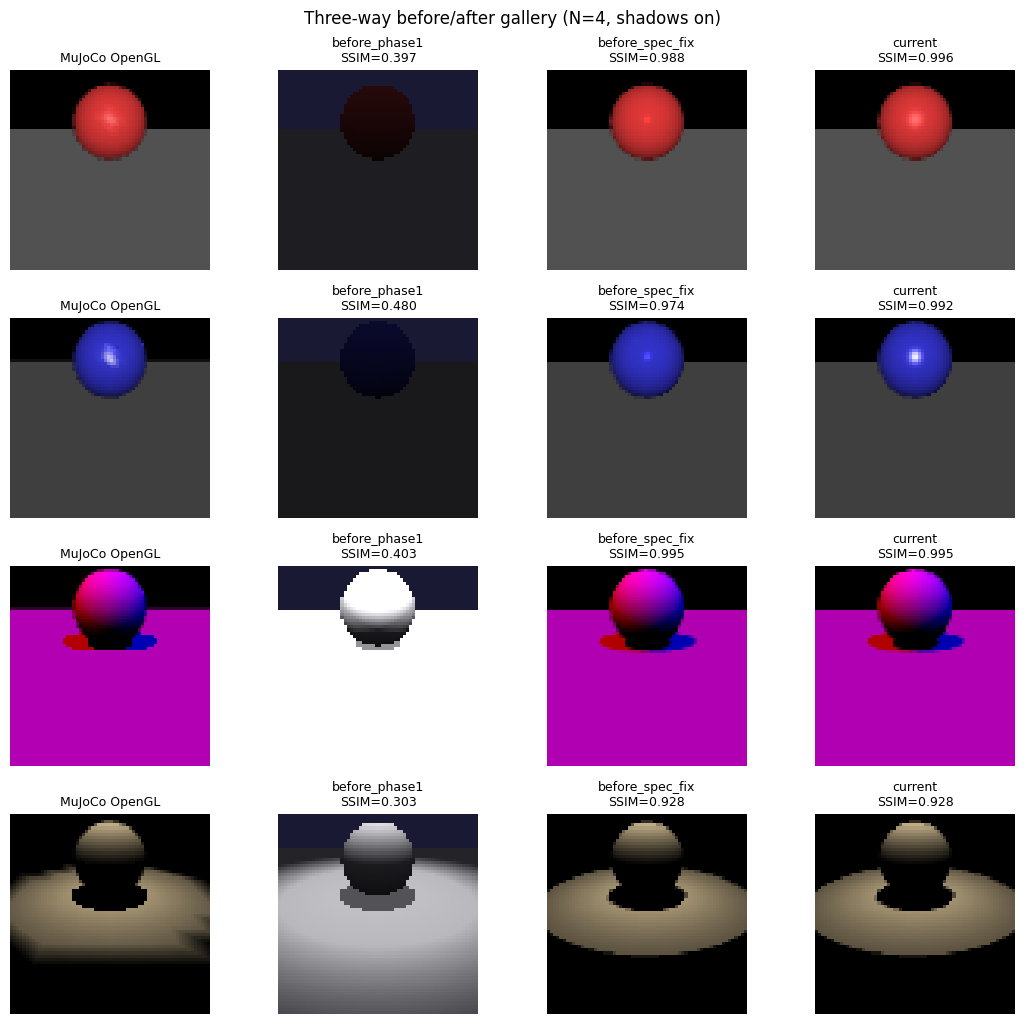

In [26]:
from mujoco_warp._src.render_parity_test import (
  _FIXTURE_HEADLIGHT_ONLY,
  _FIXTURE_SPECULAR,
  _FIXTURE_SPOTLIGHT,
  _FIXTURE_TWO_LIGHTS,
)

gallery_fixtures = [
  ("headlight_only", _FIXTURE_HEADLIGHT_ONLY),
  ("specular", _FIXTURE_SPECULAR),
  ("two_lights", _FIXTURE_TWO_LIGHTS),
  ("spotlight", _FIXTURE_SPOTLIGHT),
]

# Use N=4 for all panels so it's a like-for-like comparison; the baseline
# `before_phase1` ignores `samples_per_pixel` so its N=4 file is identical
# to its N=1, which is fine.
N_GALLERY = 4

fig, axes = plt.subplots(len(gallery_fixtures), 4, figsize=(11, 2.6 * len(gallery_fixtures)))
for row, (name, xml) in enumerate(gallery_fixtures):
  mjm = mujoco.MjModel.from_xml_string(xml)
  ref = mujoco_render(mjm, 64, 64, use_shadows=True)
  before_p1 = load_baseline_image("before_phase1", name, N_GALLERY)
  before_sf = load_baseline_image("before_spec_fix", name, N_GALLERY)
  current = mjwarp_render(mjm, 64, 64, use_shadows=True, samples_per_pixel=N_GALLERY)

  panels = [
    ("MuJoCo OpenGL", ref, None),
    ("before_phase1", before_p1, ssim_luma(before_p1, ref)),
    ("before_spec_fix", before_sf, ssim_luma(before_sf, ref)),
    ("current", current, ssim_luma(current, ref)),
  ]
  for col, (label, img, ssim) in enumerate(panels):
    axes[row, col].imshow(img, interpolation="nearest")
    title = label if ssim is None else f"{label}\nSSIM={ssim:.3f}"
    axes[row, col].set_title(title, fontsize=9)
    axes[row, col].axis("off")
  axes[row, 0].set_ylabel(name, fontsize=10, rotation=0, labelpad=40, va="center")
fig.suptitle(f"Three-way before/after gallery (N={N_GALLERY}, shadows on)")
plt.tight_layout()
plt.show()

### SSIM-vs-MuJoCo by baseline

For each fixture and baseline, computes SSIM(baseline_image, mujoco_reference)
at N=1. Shows quantitatively how much parity each commit added.

In [27]:
from mujoco_warp._src.render_parity_test import _FIXTURE_EMISSION

fixtures_for_table = [
  ("headlight_only", _FIXTURE_HEADLIGHT_ONLY),
  ("spotlight", _FIXTURE_SPOTLIGHT),
  ("specular", _FIXTURE_SPECULAR),
  ("two_lights", _FIXTURE_TWO_LIGHTS),
  ("emission", _FIXTURE_EMISSION),
]

print(f"SSIM vs MuJoCo OpenGL @ N=1, shadows on (higher is better):")
print(f"  {'fixture':<18s}  {'before_phase1':>14s}  {'before_spec_fix':>16s}  {'current':>9s}")
for name, xml in fixtures_for_table:
  mjm = mujoco.MjModel.from_xml_string(xml)
  ref = mujoco_render(mjm, 64, 64, use_shadows=True)
  bp1 = load_baseline_image("before_phase1", name, 1)
  bsf = load_baseline_image("before_spec_fix", name, 1)
  cur = mjwarp_render(mjm, 64, 64, use_shadows=True, samples_per_pixel=1)
  print(
    f"  {name:<18s}  "
    f"{ssim_luma(bp1, ref):>14.4f}  "
    f"{ssim_luma(bsf, ref):>16.4f}  "
    f"{ssim_luma(cur, ref):>9.4f}"
  )

SSIM vs MuJoCo OpenGL @ N=1, shadows on (higher is better):
  fixture              before_phase1   before_spec_fix    current
  headlight_only              0.3968            0.9833     0.9915
  spotlight                   0.3030            0.9165     0.9165
  specular                    0.4799            0.9680     0.9856
  two_lights                  0.4027            0.9937     0.9937
  emission                    0.5255            0.9939     0.9939


### Performance: before vs after

Per-frame render time vs resolution at `samples_per_pixel=1`, for each
baseline plus the current branch. The `before_phase1` line should track
the old single-ray, no-MSAA renderer; `before_spec_fix` has a heavier
kernel (extra lighting math, MSAA loop infrastructure even at N=1); and
`current` adds two more lookups for the corrected specular split. The
expectation is that the deltas between lines are small (single-digit ms
on the bench scene) — i.e. the parity work didn't tank perf.

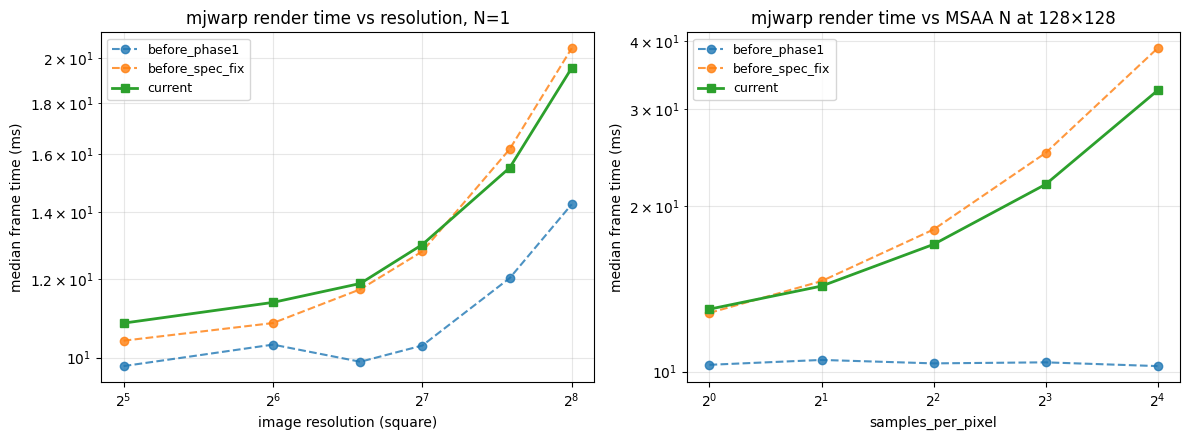

per-frame ms at N=1, single world:
  res          before_phase1   before_spec_fix    current    Δ_total
    32²                9.81             10.40      10.83      +1.02
    64²               10.31             10.83      11.36      +1.06
    96²                9.91             11.71      11.87      +1.97
   128²               10.29             12.79      12.99      +2.70
   192²               12.02             16.20      15.51      +3.49
   256²               14.26             20.45      19.54      +5.28


In [28]:
# Time the current branch on the same scene + resolutions used in the
# captured baselines so the comparison is apples-to-apples.
current_perf = {"warp_time_by_n_by_res_ms": {}}
for n in MSAA_NS:
  current_perf["warp_time_by_n_by_res_ms"][str(n)] = {
    str(r): bench_mjwarp_n(mjm_bench, r, r, nworld=1, samples_per_pixel=n) * 1000 for r in resolutions
  }

baseline_perfs = {lbl: load_baseline_perf(lbl) for lbl in BASELINE_LABELS}

# Plot N=1 across all three states.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: resolution sweep at N=1
ax = axes[0]
for lbl, perf in baseline_perfs.items():
  ys = [perf["warp_time_by_n_by_res_ms"]["1"][str(r)] for r in resolutions]
  ax.plot(resolutions, ys, "o--", label=f"{lbl}", alpha=0.8)
cur_ys = [current_perf["warp_time_by_n_by_res_ms"]["1"][str(r)] for r in resolutions]
ax.plot(resolutions, cur_ys, "s-", label="current", color="C2", linewidth=2)
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("median frame time (ms)")
ax.set_title("mjwarp render time vs resolution, N=1")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)

# Right: time at fixed 128x128 across N
ax = axes[1]
target_res = "128"
for lbl, perf in baseline_perfs.items():
  ys = [perf["warp_time_by_n_by_res_ms"][str(n)].get(target_res) for n in MSAA_NS]
  ax.plot(MSAA_NS, ys, "o--", label=f"{lbl}", alpha=0.8)
cur_ys = [current_perf["warp_time_by_n_by_res_ms"][str(n)][target_res] for n in MSAA_NS]
ax.plot(MSAA_NS, cur_ys, "s-", label="current", color="C2", linewidth=2)
ax.set_xlabel("samples_per_pixel")
ax.set_ylabel("median frame time (ms)")
ax.set_title(f"mjwarp render time vs MSAA N at {target_res}×{target_res}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print a per-resolution delta table at N=1.
print(f"per-frame ms at N=1, single world:")
print(f"  {'res':<10s}  {'before_phase1':>14s}  {'before_spec_fix':>16s}  {'current':>9s}  {'Δ_total':>9s}")
for r in resolutions:
  bp1 = baseline_perfs["before_phase1"]["warp_time_by_n_by_res_ms"]["1"][str(r)]
  bsf = baseline_perfs["before_spec_fix"]["warp_time_by_n_by_res_ms"]["1"][str(r)]
  cur = current_perf["warp_time_by_n_by_res_ms"]["1"][str(r)]
  print(f"  {r:>4d}²       {bp1:>13.2f}   {bsf:>15.2f}   {cur:>8.2f}   {cur - bp1:>+8.2f}")

### Performance: world scaling before vs after

Per-world cost at 64×64 across world counts, comparing each baseline to
the current branch at N=1. Verifies the batching behavior didn't regress.

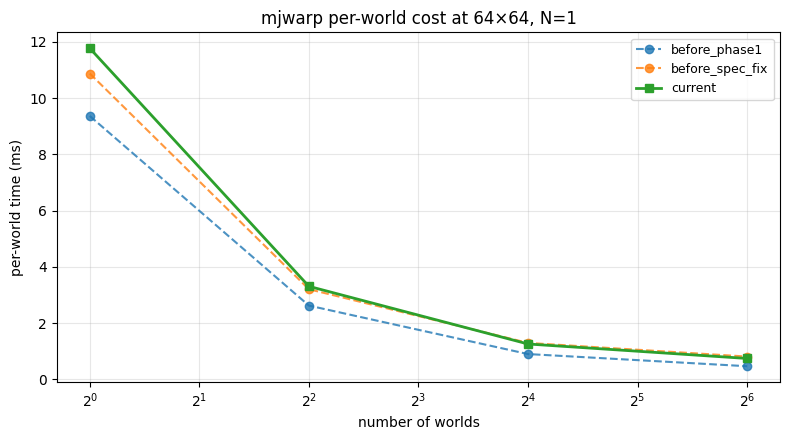

per-world ms at N=1, 64×64:
  worlds       before_phase1   before_spec_fix    current
       1             9.361            10.871     11.770
       4             2.621             3.203      3.306
      16             0.898             1.294      1.256
      64             0.466             0.809      0.741


In [29]:
# Use the world_counts from the existing perf section + filter to those
# that every baseline also captured (so cuda/cpu mismatches don't blow up).
common_world_counts = sorted(
  set(world_counts) & set(int(w) for w in baseline_perfs["before_phase1"]["warp_time_by_n_by_world_ms"]["1"].keys())
)

current_world_n1 = {w: bench_mjwarp_n(mjm_bench, 64, 64, nworld=w, samples_per_pixel=1) * 1000 for w in common_world_counts}

fig, ax = plt.subplots(figsize=(8, 4.5))
for lbl, perf in baseline_perfs.items():
  ys = [perf["warp_time_by_n_by_world_ms"]["1"][str(w)] / w for w in common_world_counts]
  ax.plot(common_world_counts, ys, "o--", label=lbl, alpha=0.8)
cur_ys = [current_world_n1[w] / w for w in common_world_counts]
ax.plot(common_world_counts, cur_ys, "s-", label="current", color="C2", linewidth=2)
ax.set_xlabel("number of worlds")
ax.set_ylabel("per-world time (ms)")
ax.set_title("mjwarp per-world cost at 64×64, N=1")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"per-world ms at N=1, 64×64:")
print(f"  {'worlds':<10s}  {'before_phase1':>14s}  {'before_spec_fix':>16s}  {'current':>9s}")
for w in common_world_counts:
  bp1 = baseline_perfs["before_phase1"]["warp_time_by_n_by_world_ms"]["1"][str(w)] / w
  bsf = baseline_perfs["before_spec_fix"]["warp_time_by_n_by_world_ms"]["1"][str(w)] / w
  cur = current_world_n1[w] / w
  print(f"  {w:>6d}     {bp1:>13.3f}   {bsf:>15.3f}   {cur:>8.3f}")

## Summary

If all the side-by-side comparisons above show mjwarp tracking MuJoCo OpenGL
qualitatively (and the SSIM table at section 8 is all green), the Phase 1
parity work is functioning end-to-end on this build.

Remaining differences in the diff panels (e.g. the spot cone boundary,
ball silhouette, specular hotspot shape) are structural consequences of
per-pixel ray tracing vs per-vertex Gouraud shading and cannot be fully
closed without changing the rasterized reference itself. Phase 2/3 will
*widen* the gap in mjwarp's favor (soft shadows, Fresnel, GGX) — Phase 1's
goal was just to make mjwarp respond to the same knobs that OpenGL does.